# Loading google drive and cloning git project

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/brain-glioma-classifier'

import os

if os.path.exists('brain-glioma-classifier'):
    # already cloned — just pull latest changes
    !git -C brain-glioma-classifier pull
else:
    # fresh session — clone from scratch
    !git clone https://github.com/yotamcooper/brain-glioma-classifier.git

%cd brain-glioma-classifier
!pip install -r requirements.txt -q

Mounted at /content/drive
Cloning into 'brain-glioma-classifier'...
remote: Enumerating objects: 26332, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 26332 (delta 18), reused 28 (delta 10), pack-reused 26294 (from 2)
Receiving objects: 100% (26332/26332), 273.14 MiB | 18.88 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/brain-glioma-classifier/brain-glioma-classifier


### Unziping data

In [3]:
import os
os.makedirs('data', exist_ok=True)

!cp "{DRIVE_BASE}/data.zip" /content/data.zip
print("Copy done, extracting...")

!unzip -o -q /content/data.zip -d data/
print("Data ready ✅")

# check that the data unziped correct
folders = os.listdir('data')
print(f"Items in data/: {folders}")
print(f"Total count: {len(folders)}")

Copy done, extracting...
Data ready ✅
Items in data/: ['Brain Tumor MRI Dataset', 'Brain Tumor MRI Dataset Raw', '.gitkeep', 'TCGA_GBM_LGG_Mutations_all.csv']
Total count: 4


##Stage 1 cell

Found 18571 images belonging to 2 classes.
Found 3977 images belonging to 2 classes.
Found 3977 images belonging to 2 classes.
Train : 18,571 images
Val   : 3,977 images
Test  : 3,977 images
Class mapping: {'No Tumor': 0, 'Tumor': 1}
Stage 1 model loaded | trained at: 2026-04-07T15:00:12.018970
History loaded ✅


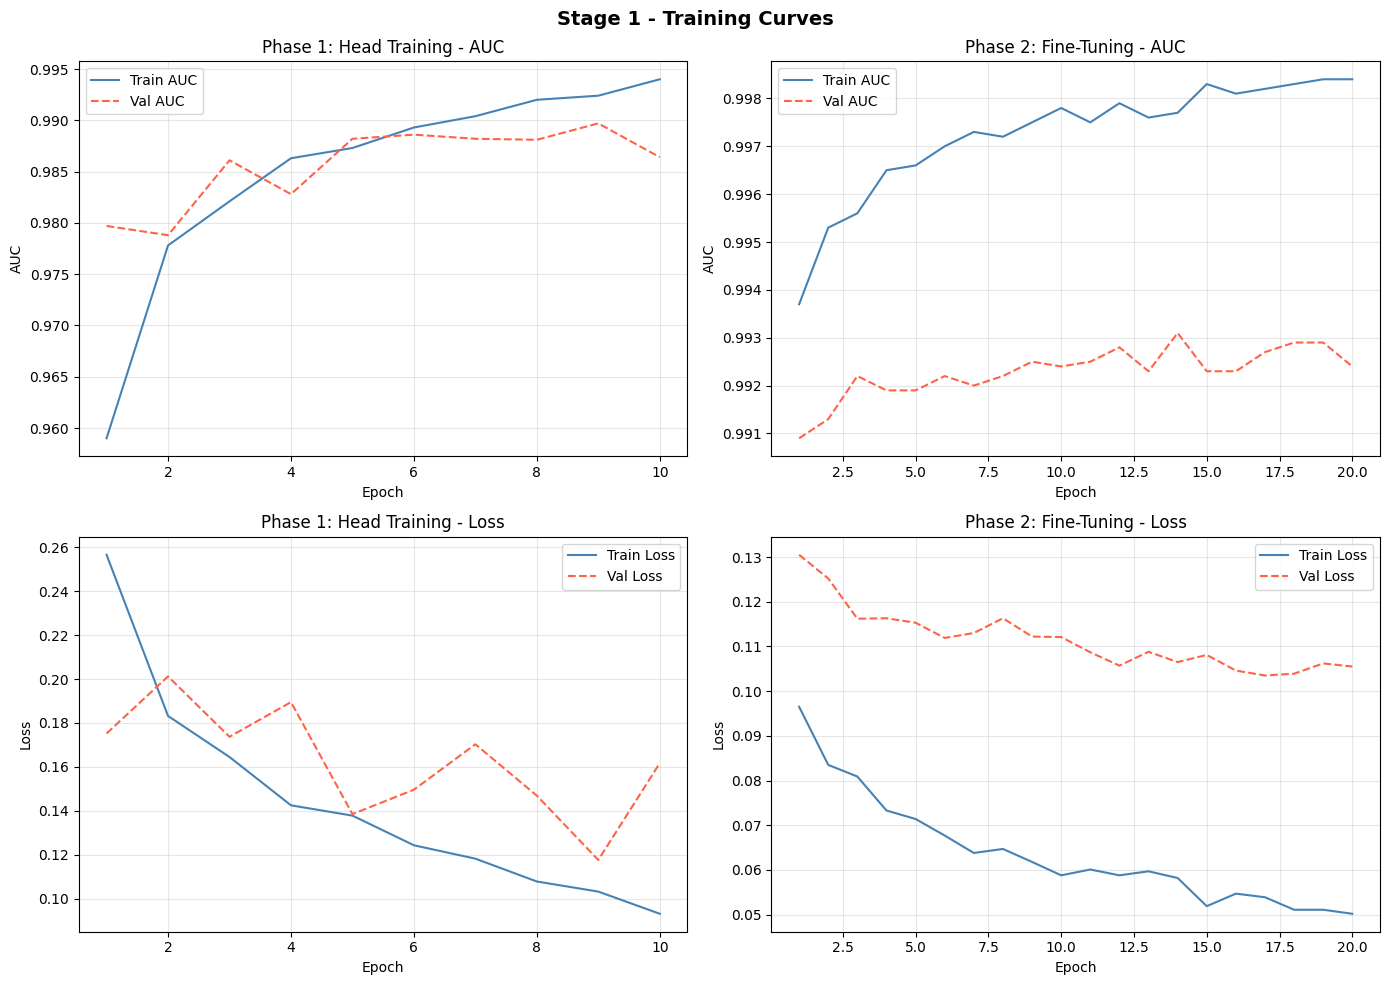

Training curves saved to: figures/stage1_training_curves.png
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step

  Stage 1 - Tumor Detector Results
  AUC Score             : 0.9958
  Accuracy              : 97.31%
  Optimal Threshold     : 0.2078
  Sensitivity (TPR)     : 96.73%
  Specificity (TNR)     : 97.89%
  False Negatives       : 65  (missed tumors)
  False Positives       : 42  (healthy misclassified)

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.97      0.98      0.97      1990
       Tumor       0.98      0.97      0.97      1987

    accuracy                           0.97      3977
   macro avg       0.97      0.97      0.97      3977
weighted avg       0.97      0.97      0.97      3977

Results table saved to: figures/results_table_stage1.png


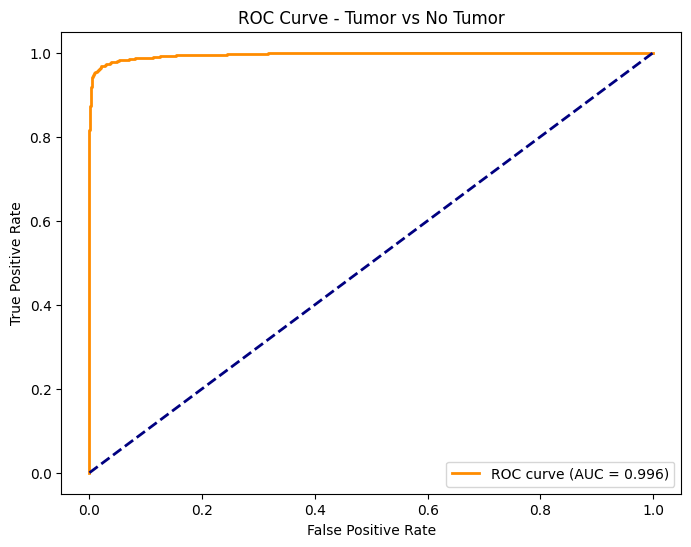

AUC: 0.996 | Optimal threshold: 0.208
At threshold -> FPR: 0.021, TPR: 0.967


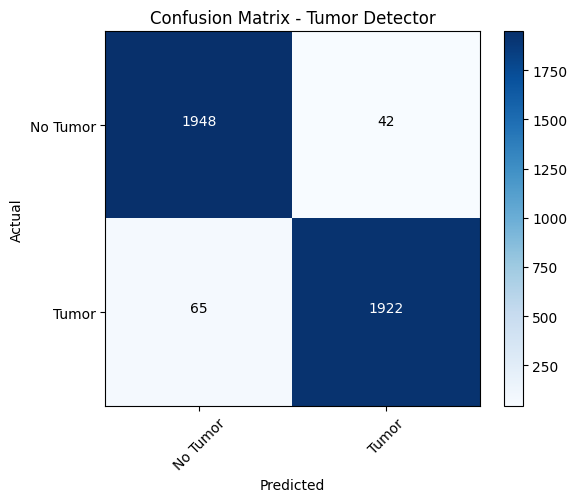

Confusion matrix saved to: figures/confusion_matrix_stage1.png
✅ Stage 1 loaded from Drive!


In [4]:
from src.pipeline import run_stage1
import os


drive_model = f"{DRIVE_BASE}/models/stage1_final.keras"

if os.path.exists(drive_model):
    # Copy from Drive to local
    os.makedirs("models", exist_ok=True)
    !cp "{DRIVE_BASE}/models/stage1_final.keras" models/
    !cp "{DRIVE_BASE}/models/stage1_metadata.json" models/
    !cp "{DRIVE_BASE}/models/stage1_history.json" models/
    load_saved = True
else:
    load_saved = False

model, history = run_stage1(load_saved=load_saved)

if not load_saved:
    os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
    os.makedirs(f"{DRIVE_BASE}/figures", exist_ok=True)
    !cp models/stage1_final.keras "{DRIVE_BASE}/models/"
    !cp models/stage1_metadata.json "{DRIVE_BASE}/models/"
    !cp models/stage1_history.json "{DRIVE_BASE}/models/"
    !cp models/stage1_phase1_best.keras "{DRIVE_BASE}/models/"
    !cp models/stage1_phase2_best.keras "{DRIVE_BASE}/models/"
    !cp -r figures/ "{DRIVE_BASE}/figures/"
    print("✅ Stage 1 trained and saved to Drive!")
else:
    print("✅ Stage 1 loaded from Drive!")

## Stage 2 cell

Patients: 862, Columns: 27
Grade distribution:
Grade
LGG    499
GBM    363
Name: count, dtype: int64

Dataset: 862 patients, 23 features

Stage 2 model loaded | type: Logistic Regression | trained at: 2026-04-07T16:08:10.209744

  Stage 2 - Grading Model Results
  Model                 : Logistic Regression
  AUC Score             : 0.9374
  Accuracy              : 88.44%
  Sensitivity (TPR)     : 86.00%
  Specificity (TNR)     : 91.78%
  False Negatives       : 14  (missed GBM)
  False Positives       : 6  (LGG misclassified)

Classification Report:
              precision    recall  f1-score   support

         GBM       0.83      0.92      0.87        73
         LGG       0.93      0.86      0.90       100

    accuracy                           0.88       173
   macro avg       0.88      0.89      0.88       173
weighted avg       0.89      0.88      0.88       173



/content/brain-glioma-classifier/brain-glioma-classifier/src/preprocessing.py:64: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[mutation_cols] = X[mutation_cols].replace({'MUTATED': 1, 'NOT_MUTATED': 0}).infer_objects(copy=False)


Results table saved to: figures/results_table_stage2.png


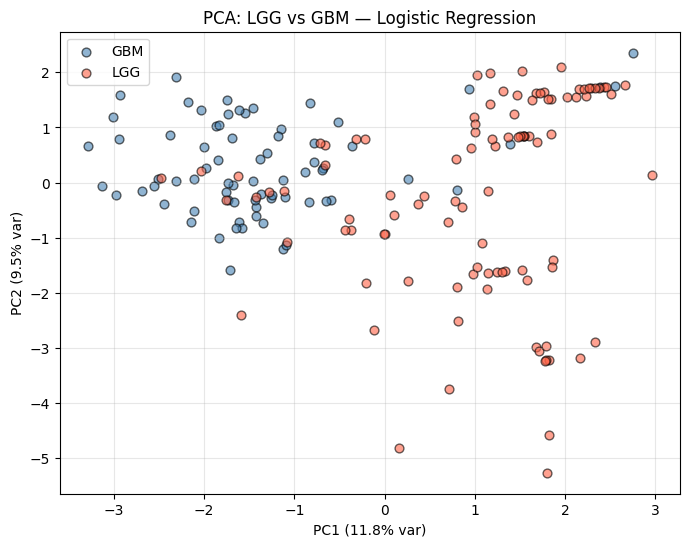

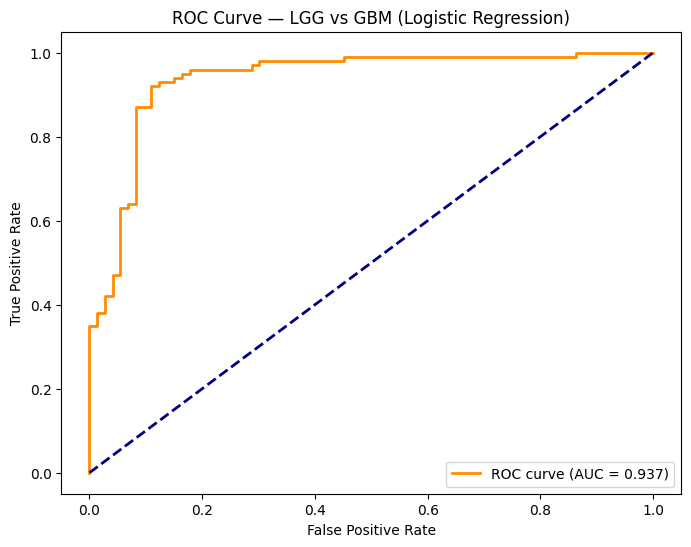

AUC: 0.937 | Optimal threshold: 0.315
At threshold -> FPR: 0.110, TPR: 0.920


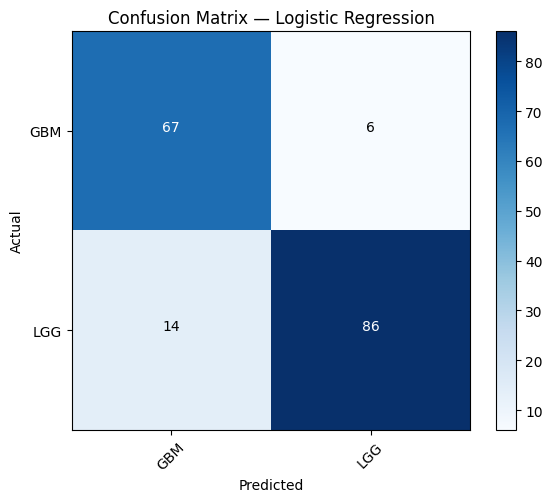

Confusion matrix saved to: figures/confusion_matrix_stage2.png


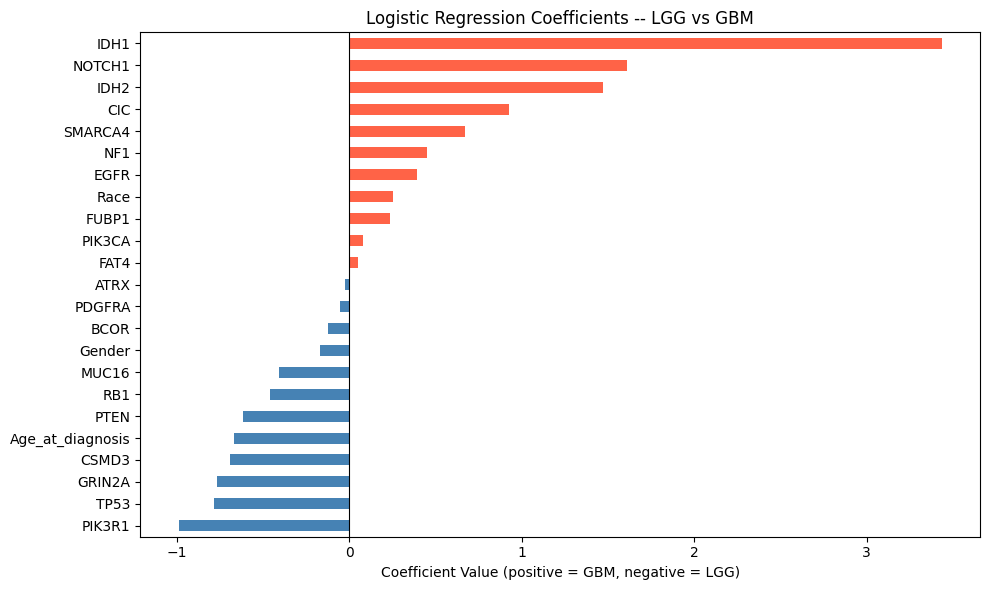

✅ Stage 2 loaded from Drive!


In [5]:
from src.pipeline import run_stage2
import os

drive_model = f"{DRIVE_BASE}/models/stage2_final.joblib"

if os.path.exists(drive_model):
    os.makedirs("models", exist_ok=True)
    !cp "{DRIVE_BASE}/models/stage2_final.joblib" models/
    !cp "{DRIVE_BASE}/models/stage2_metadata.json" models/
    load_saved = True
else:
    load_saved = False

run_stage2(load_saved=load_saved)

if not load_saved:
    os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
    os.makedirs(f"{DRIVE_BASE}/figures", exist_ok=True)
    !cp models/stage2_final.joblib "{DRIVE_BASE}/models/"
    !cp models/stage2_metadata.json "{DRIVE_BASE}/models/"
    !cp -r figures/ "{DRIVE_BASE}/figures/"
    print("✅ Stage 2 trained and saved to Drive!")
else:
    print("✅ Stage 2 loaded from Drive!")

In [ ]:
# Testing Stage 1 predict
# needs a folder that has the images in you can change the link to whatever
from src.predict import predict_tumor

result = predict_tumor("data/Brain Tumor MRI Dataset/test/Tumor")
print(result)

## Stage 2 Predctions

In [ ]:
# Testing Stage 2 predict
# the input is a dict so whatever patient details you give itll predict
from src.predict import predict_grading

result = predict_grading({
    "Age_at_diagnosis": "52 years 180 days",
    "Gender": "Male",
    "Race": "white",
    "IDH1": "MUTATED",
    "TP53": "NOT_MUTATED",
    "ATRX": "NOT_MUTATED",
    "PTEN": "NOT_MUTATED",
    "EGFR": "NOT_MUTATED",
    "CIC": "NOT_MUTATED",
    "MUC16": "NOT_MUTATED",
    "PIK3CA": "NOT_MUTATED",
    "NF1": "NOT_MUTATED",
    "PIK3R1": "NOT_MUTATED",
    "FUBP1": "NOT_MUTATED",
    "RB1": "NOT_MUTATED",
    "NOTCH1": "NOT_MUTATED",
    "BCOR": "NOT_MUTATED",
    "CSMD3": "NOT_MUTATED",
    "SMARCA4": "NOT_MUTATED",
    "GRIN2A": "NOT_MUTATED",
    "IDH2": "NOT_MUTATED",
    "FAT4": "NOT_MUTATED",
    "PDGFRA": "NOT_MUTATED",
})
print(result)